# Importing Libraries

In [1]:
import pickle
import joblib

# Loading Files

In [2]:
! gdown 14FyiVsMhY2MEZbYLM2-KpfwS3jox1MNW
! gdown 14aX31S8LuuiSIpJQmn8H7hK7RhJUwGzp
! gdown 1swLiZFTafjJQssF0DId1qw4-mtoR8h5n
! gdown 1PFUPU-DEAf0IXvy8mI_LozS4AAPeEupj
! gdown 1pJ2QA6v7dxA5KmG_GSfs_OHzYXaFfJUN

Downloading...
From: https://drive.google.com/uc?id=14FyiVsMhY2MEZbYLM2-KpfwS3jox1MNW
To: /content/y_prob_bert.pkl
100% 63.3k/63.3k [00:00<00:00, 62.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=14aX31S8LuuiSIpJQmn8H7hK7RhJUwGzp
To: /content/y_prob_LightGBM.pkl
100% 126k/126k [00:00<00:00, 61.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1swLiZFTafjJQssF0DId1qw4-mtoR8h5n
To: /content/y_prob_lr.pkl
100% 126k/126k [00:00<00:00, 71.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1PFUPU-DEAf0IXvy8mI_LozS4AAPeEupj
To: /content/y_prob_nb.pkl
100% 126k/126k [00:00<00:00, 121MB/s]
Downloading...
From: https://drive.google.com/uc?id=1pJ2QA6v7dxA5KmG_GSfs_OHzYXaFfJUN
To: /content/y_prob_stack.pkl
100% 126k/126k [00:00<00:00, 90.3MB/s]


In [3]:
! gdown 1Az4qS0h_xHgR62O338949jrlwfMal11F

Downloading...
From: https://drive.google.com/uc?id=1Az4qS0h_xHgR62O338949jrlwfMal11F
To: /content/y_test.pkl
100% 506k/506k [00:00<00:00, 115MB/s]


# ROC-AUC curve

In [4]:
y_prob_bert = joblib.load('/content/y_prob_bert.pkl')
y_prob_lr = joblib.load('/content/y_prob_lr.pkl')
y_prob_LightGBM = joblib.load('/content/y_prob_LightGBM.pkl')
y_prob_nb = joblib.load('/content/y_prob_nb.pkl')
y_prob_stack= joblib.load('/content/y_prob_stack.pkl')
y_test = joblib.load('/content/y_test.pkl')

In [5]:
from sklearn.metrics import roc_curve, auc

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)

fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
auc_nb = auc(fpr_nb, tpr_nb)

fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, y_prob_LightGBM)
auc_lgbm = auc(fpr_lgbm, tpr_lgbm)

fpr_stack, tpr_stack, _ = roc_curve(y_test, y_prob_stack)
auc_stack = auc(fpr_stack, tpr_stack)

fpr_bert, tpr_bert, _ = roc_curve(y_test, y_prob_bert)
auc_bert = auc(fpr_bert, tpr_bert)

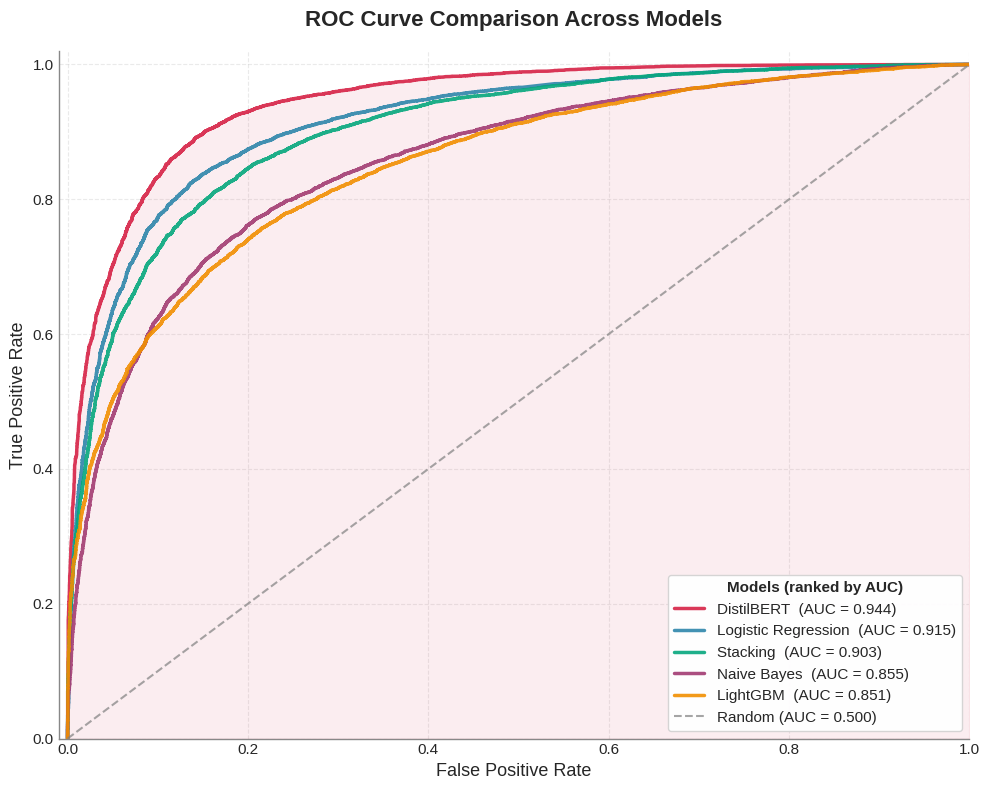

In [6]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(10, 8), dpi=100)

colors = {
    'lr':    '#2E86AB',   # blue
    'nb':    '#A23B72',   # magenta
    'lgbm':  '#F18F01',   # orange
    'stack': '#06A77D',   # green
    'bert':  '#D62246',   # red
}

models = [
    (fpr_lr,    tpr_lr,    auc_lr,    'Logistic Regression', colors['lr']),
    (fpr_nb,    tpr_nb,    auc_nb,    'Naive Bayes',         colors['nb']),
    (fpr_lgbm,  tpr_lgbm,  auc_lgbm,  'LightGBM',            colors['lgbm']),
    (fpr_stack, tpr_stack, auc_stack, 'Stacking',            colors['stack']),
    (fpr_bert,  tpr_bert,  auc_bert,  'DistilBERT',          colors['bert']),
]

models.sort(key=lambda m: m[2], reverse=True)

for fpr, tpr, auc, name, color in models:
    ax.plot(fpr, tpr, color=color, lw=2.5, alpha=0.9,
            label=f'{name}  (AUC = {auc:.3f})')
    # Subtle fill under the curve of the best model
    if auc == models[0][2]:
        ax.fill_between(fpr, tpr, alpha=0.08, color=color)

ax.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--',
        alpha=0.7, label='Random (AUC = 0.500)')

ax.set_xlim([-0.01, 1.0])
ax.set_ylim([0.0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=13, fontweight='medium')
ax.set_ylabel('True Positive Rate',  fontsize=13, fontweight='medium')
ax.set_title('ROC Curve Comparison Across Models',
             fontsize=16, fontweight='bold', pad=18)

ax.tick_params(axis='both', labelsize=11)

legend = ax.legend(loc='lower right', fontsize=11, frameon=True,
                   fancybox=True, shadow=False, framealpha=0.95,
                   edgecolor='lightgray', title='Models (ranked by AUC)',
                   title_fontsize=11)
legend.get_title().set_fontweight('bold')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color('#888888')

ax.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()